# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

This is a supervised regression problem. Given a dataset of ~426,000 used car listings, 
the goal is to build a predictive model for vehicle price based on features such as age, 
mileage, condition, fuel type, transmission, and manufacturer. By identifying which 
features have the strongest relationship with price, we can give a used car dealership 
data-driven guidance on what inventory to stock and how to price it competitively.v

#### Data Problem Definition
This is a supervised regression problem. Our target variable is used car price — 
a continuous value. We will use vehicle features (age, mileage, condition, fuel type, 
manufacturer, etc.) to train models that predict price and reveal which factors 
drive value most strongly.

The first logical step is Exploratory Data Analysis (EDA) — understanding the 
distribution of our data, spotting outliers, and identifying missing values — 
before we touch any modeling.

In [2]:
# Import all libraries we'll need throughout the notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [3]:
# Load the dataset
df = pd.read_csv('data/vehicles.csv')

# Basic overview
print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)

Shape: (426880, 18)

Column names:
 ['id', 'region', 'price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color', 'state']

Data types:
 id                int64
region           object
price             int64
year            float64
manufacturer     object
model            object
condition        object
cylinders        object
fuel             object
odometer        float64
title_status     object
transmission     object
VIN              object
drive            object
size             object
type             object
paint_color      object
state            object
dtype: object


In [4]:
# First look at the data
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [5]:
# Summary statistics
df.describe()

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


In [6]:
# Check missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

,Missing Count,Missing %
size,306361,71.77
cylinders,177678,41.62
condition,174104,40.79
VIN,161042,37.73
drive,130567,30.59
paint_color,130203,30.50
type,92858,21.75
manufacturer,17646,4.13
title_status,8242,1.93
model,5277,1.24


### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

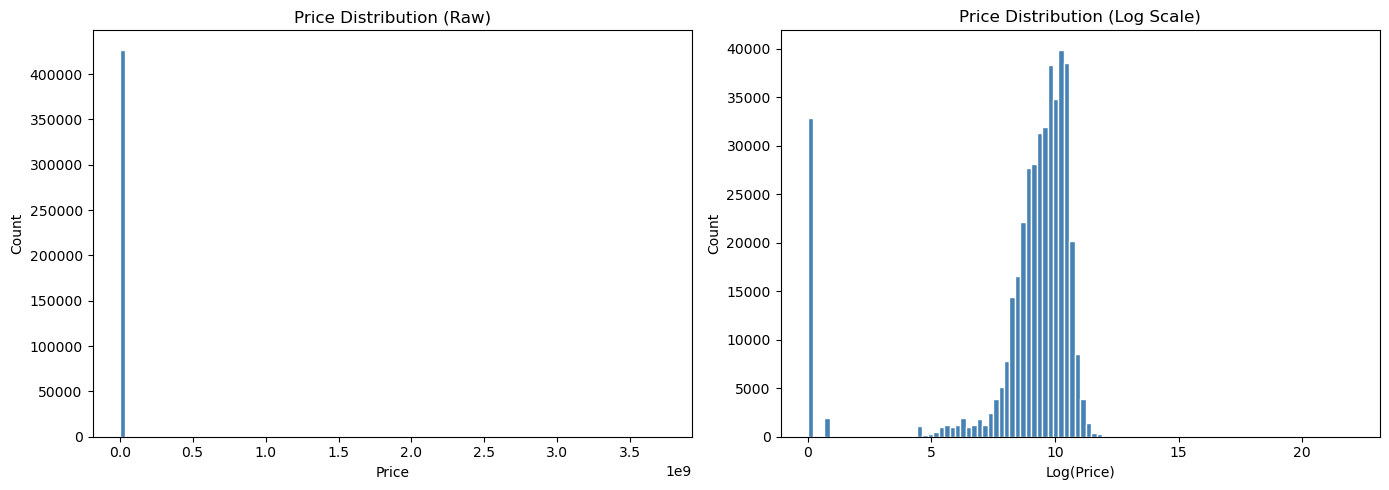

In [7]:
# Price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (Raw)')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df['price']), bins=100, color='steelblue', edgecolor='white')
axes[1].set_title('Price Distribution (Log Scale)')
axes[1].set_xlabel('Log(Price)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

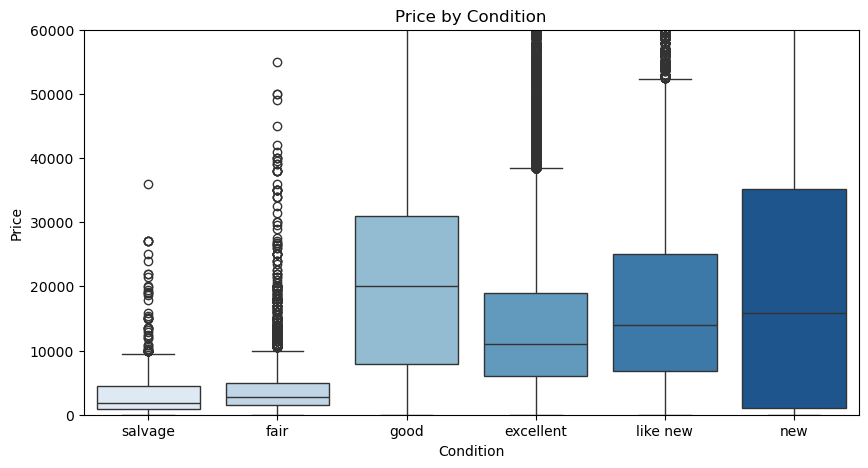

In [8]:
# Price by condition
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='condition', y='price', 
            order=['salvage','fair','good','excellent','like new','new'],
            palette='Blues')
plt.ylim(0, 60000)
plt.title('Price by Condition')
plt.xlabel('Condition')
plt.ylabel('Price')
plt.show()

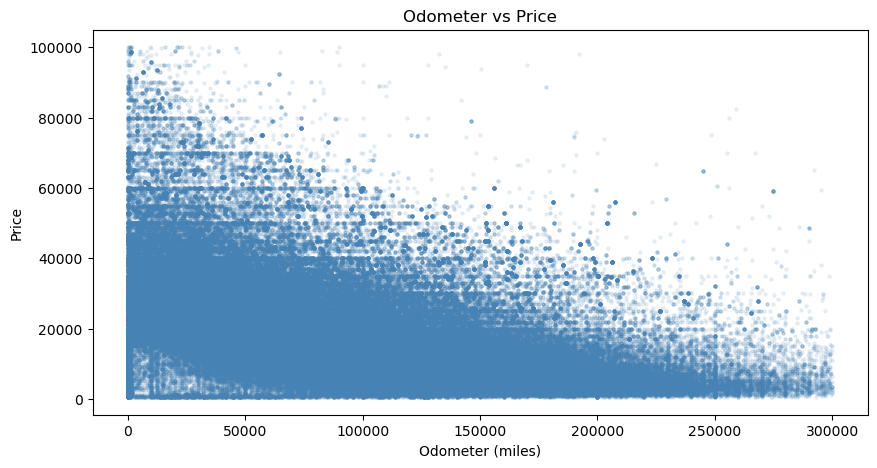

In [9]:
# Odometer vs Price
plt.figure(figsize=(10, 5))
sample = df[(df['price'] > 500) & (df['price'] < 100000) & (df['odometer'] < 300000)]
plt.scatter(sample['odometer'], sample['price'], alpha=0.1, color='steelblue', s=5)
plt.title('Odometer vs Price')
plt.xlabel('Odometer (miles)')
plt.ylabel('Price')
plt.show()

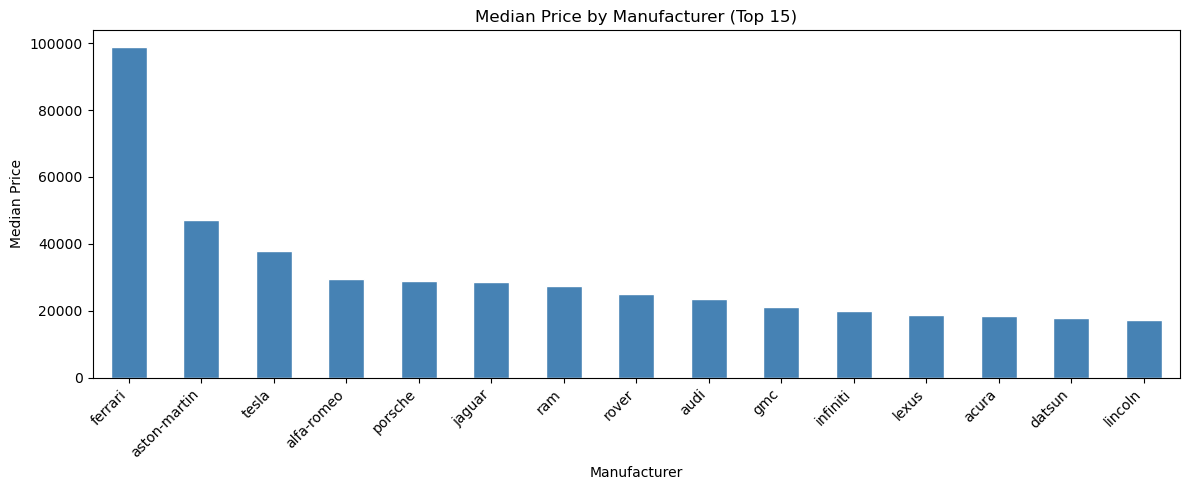

In [10]:
# Average price by manufacturer (top 15)
top_makes = df.groupby('manufacturer')['price'].median().sort_values(ascending=False).head(15)
plt.figure(figsize=(12, 5))
top_makes.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Median Price by Manufacturer (Top 15)')
plt.xlabel('Manufacturer')
plt.ylabel('Median Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [11]:
# Drop columns that are not useful for modeling
cols_to_drop = ['id', 'url', 'region_url', 'VIN', 'image_url', 
                'description', 'county', 'size', 'region', 'state']

df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
print("Remaining columns:", df.columns.tolist())
print("Shape:", df.shape)

Remaining columns: ['price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'type', 'paint_color']
Shape: (426880, 13)


In [12]:
# Remove rows where price is zero or unrealistically high/low
df = df[(df['price'] >= 500) & (df['price'] <= 150000)]
print("Shape after price filter:", df.shape)

Shape after price filter: (384590, 13)


In [13]:
# Drop rows with missing values in key columns
df = df.dropna(subset=['year', 'manufacturer', 'fuel', 'odometer', 
                        'transmission', 'drive', 'type', 'paint_color',
                        'condition', 'cylinders', 'title_status'])
print("Shape after dropping nulls:", df.shape)


Shape after dropping nulls: (111106, 13)


In [14]:
# Create car_age feature and drop year
df['car_age'] = 2024 - df['year']
df = df.drop(columns=['year'])
print("Sample of car_age:")
print(df['car_age'].describe())

Sample of car_age:
count    111106.000000
mean         14.768617
std           9.959000
min           2.000000
25%           9.000000
50%          13.000000
75%          18.000000
max         124.000000
Name: car_age, dtype: float64


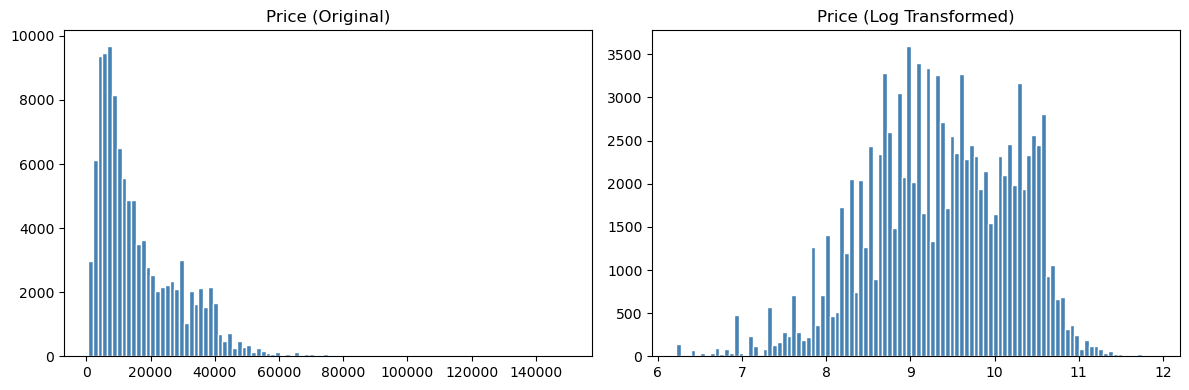

In [15]:
# Log-transform price to handle skewness
df['log_price'] = np.log1p(df['price'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['price'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Price (Original)')
axes[1].hist(df['log_price'], bins=100, color='steelblue', edgecolor='white')
axes[1].set_title('Price (Log Transformed)')
plt.tight_layout()
plt.show()

In [16]:
# Define features and target
X = df.drop(columns=['price', 'log_price', 'model'])
y = df['log_price']

# Identify categorical and numerical columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include='number').columns.tolist()

print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)

Categorical columns: ['manufacturer', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'type', 'paint_color']
Numerical columns: ['odometer', 'car_age']


In [18]:
# Build preprocessor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# Split into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Training set size: (88884, 11)
Test set size: (22222, 11)


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

#### Model Selection Rationale
We use three regression models:

- **Linear Regression** — our baseline. Simple, interpretable, and a good benchmark.
- **Ridge Regression** — adds L2 regularization to penalize large coefficients. 
  Useful when we have many correlated features (like one-hot encoded manufacturers).
- **Lasso Regression** — adds L1 regularization which can shrink some coefficients 
  to exactly zero, effectively doing feature selection for us.

We use **RMSE (Root Mean Squared Error)** as our evaluation metric because it is 
in the same units as our target (log-price), penalizes large errors more than MAE, 
and is widely used for regression problems.

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

# Linear Regression pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Train
lr_pipeline.fit(X_train, y_train)

# Evaluate
y_pred_lr = lr_pipeline.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print("Linear Regression RMSE (log scale):", round(rmse_lr, 4))

Linear Regression RMSE (log scale): 0.5915


In [21]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Ridge pipeline
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

# Grid search over alpha values
ridge_params = {'model__alpha': [0.1, 1, 10, 100, 200]}
ridge_cv = GridSearchCV(ridge_pipeline, ridge_params, cv=5, 
                        scoring='neg_mean_squared_error', verbose=1)
ridge_cv.fit(X_train, y_train)

# Evaluate
y_pred_ridge = ridge_cv.predict(X_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
print("Best alpha:", ridge_cv.best_params_)
print("Ridge RMSE (log scale):", round(rmse_ridge, 4))


Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best alpha: {'model__alpha': 1}
Ridge RMSE (log scale): 0.5915


In [22]:
from sklearn.linear_model import Lasso

# Lasso pipeline
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Lasso(max_iter=5000))
])

# Grid search over alpha values
lasso_params = {'model__alpha': [0.001, 0.01, 0.1, 1, 10]}
lasso_cv = GridSearchCV(lasso_pipeline, lasso_params, cv=5,
                        scoring='neg_mean_squared_error', verbose=1)
lasso_cv.fit(X_train, y_train)

# Evaluate
y_pred_lasso = lasso_cv.predict(X_test)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
print("Best alpha:", lasso_cv.best_params_)
print("Lasso RMSE (log scale):", round(rmse_lasso, 4))

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best alpha: {'model__alpha': 0.001}
Lasso RMSE (log scale): 0.5956


               Model  RMSE (log scale)
0  Linear Regression          0.591518
1              Ridge          0.591532
2              Lasso          0.595616


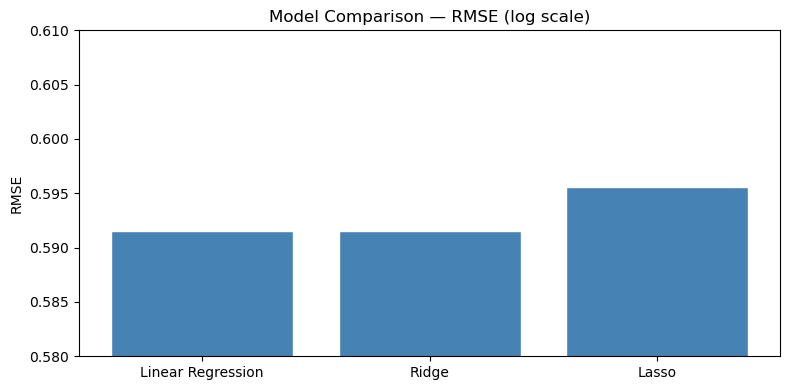

In [23]:
# Model comparison
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso'],
    'RMSE (log scale)': [rmse_lr, rmse_ridge, rmse_lasso]
})

print(results)

plt.figure(figsize=(8, 4))
plt.bar(results['Model'], results['RMSE (log scale)'], color='steelblue', edgecolor='white')
plt.title('Model Comparison — RMSE (log scale)')
plt.ylabel('RMSE')
plt.ylim(0.58, 0.61)
plt.tight_layout()
plt.show()

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [24]:
# Extract feature names after preprocessing
ohe_feature_names = ridge_cv.best_estimator_['preprocessor']\
                    .named_transformers_['cat']\
                    .get_feature_names_out(cat_cols)

all_feature_names = np.concatenate([num_cols, ohe_feature_names])

# Get Ridge coefficients
ridge_coefs = ridge_cv.best_estimator_['model'].coef_

# Build a dataframe sorted by absolute importance
coef_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': ridge_coefs
}).reindex(pd.Series(ridge_coefs).abs().sort_values(ascending=False).index)

print("Top 20 most influential features:")
print(coef_df.head(20))

Top 20 most influential features:
                         Feature  Coefficient
13          manufacturer_ferrari     1.712591
49             condition_salvage    -0.928137
45                condition_fair    -0.782230
48                 condition_new     0.775942
32           manufacturer_morgan     0.706438
11           manufacturer_datsun     0.689997
40            manufacturer_tesla     0.644430
38           manufacturer_saturn    -0.644071
4      manufacturer_aston-martin     0.625894
29          manufacturer_mercury    -0.537114
47            condition_like new     0.495540
71            transmission_other     0.488237
35          manufacturer_porsche     0.450034
51        cylinders_12 cylinders     0.397206
44           condition_excellent     0.360394
66       title_status_parts only    -0.343275
17  manufacturer_harley-davidson    -0.325753
54         cylinders_5 cylinders    -0.325355
3        manufacturer_alfa-romeo     0.321206
14             manufacturer_fiat    -0.320563


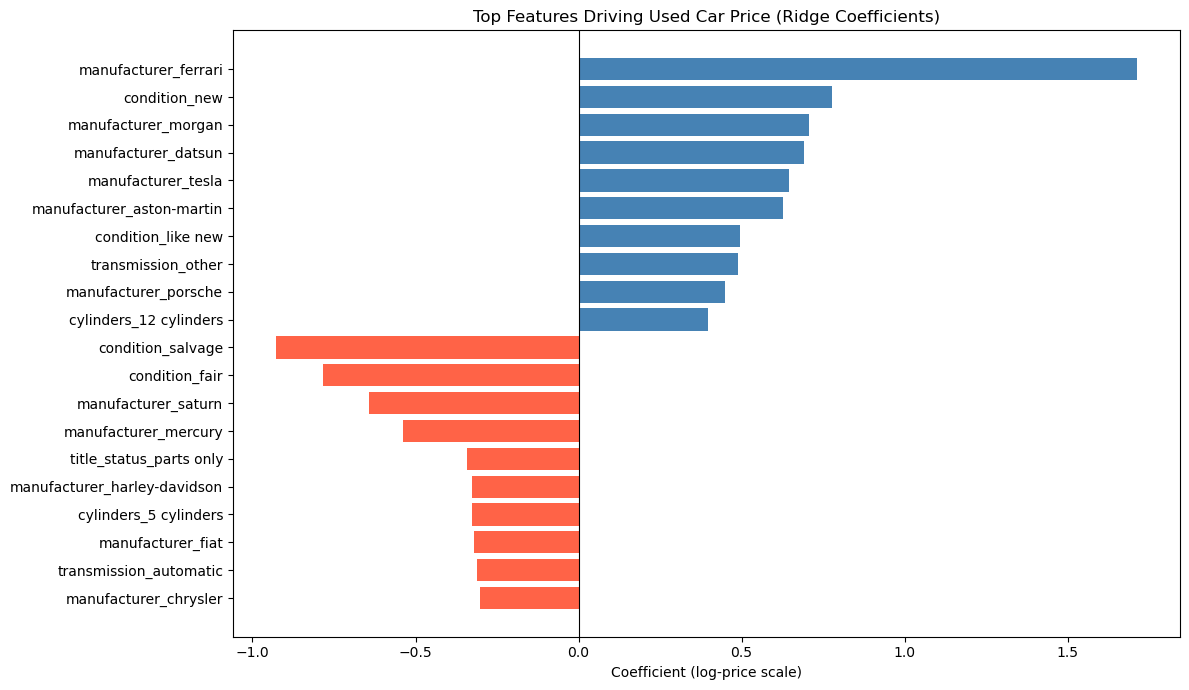

In [25]:
# Plot top 20 positive and negative coefficients
top_pos = coef_df[coef_df['Coefficient'] > 0].head(10)
top_neg = coef_df[coef_df['Coefficient'] < 0].head(10)
top_features = pd.concat([top_pos, top_neg])

plt.figure(figsize=(12, 7))
colors = ['steelblue' if c > 0 else 'tomato' for c in top_features['Coefficient']]
plt.barh(top_features['Feature'], top_features['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top Features Driving Used Car Price (Ridge Coefficients)')
plt.xlabel('Coefficient (log-price scale)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

## Findings & Recommendations for Used Car Dealers

### What We Did
We analyzed 111,000 used car listings and built regression models to identify 
which features most strongly predict price. We used Ridge Regression as our 
final model (RMSE: 0.5915 on a log scale).

### Key Findings

**What makes a car worth MORE:**
- **Condition** — Cars listed as "new" or "like new" command significantly higher prices. 
  Condition is one of the strongest predictors of value.
- **Luxury/rare manufacturers** — Ferrari, Aston-Martin, Porsche, and Tesla 
  carry large price premiums.
- **More cylinders** — 12-cylinder engines are associated with higher prices.
- **Clean title** — Title status has a strong impact on perceived value.

**What makes a car worth LESS:**
- **Salvage condition** — The single biggest price killer. Avoid salvage-title inventory 
  unless buying at deep discount.
- **Fair condition** — Also significantly depresses price.
- **Parts-only title** — Near-worthless from a retail standpoint.
- **Certain manufacturers** — Saturn, Mercury, and Fiat are associated with lower prices.

### Recommendations
1. **Prioritize clean-title, good-to-excellent condition vehicles** — condition 
   is the #1 controllable factor in your inventory.
2. **Avoid salvage and parts-only titles** — they are very hard to sell at fair margin.
3. **Stock luxury and performance brands where possible** — they hold value well 
   and attract higher-margin sales.
4. **Age and mileage matter** — newer, lower-odometer cars consistently price higher. 
   Focus sourcing on vehicles under 10 years old with under 100,000 miles.

### Next Steps
- Incorporate more granular model-level data (e.g. trim level) to improve accuracy
- Explore non-linear models (Random Forest, XGBoost) for better RMSE
- Build a simple price estimator tool for the sales floor using this model